<a href="https://www.kaggle.com/code/mdmusaislamfahad01/fifa-world-cup-2026-ml-prediction-system?scriptVersionId=322256149" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🏆 FIFA World Cup 2026 - Complete ML Prediction System

---
## 📋 Notebook Structure
| Section | Description |
|---|---------|
| 1. Setup & EDA | Setup & EDA |
| 2. Feature Engineering | Enhanced Feature Engineering (44 features) |
| 3. Model Training | Model Training - RF · ET · HGB · MLP · SVM · LR |
| 4. Stacking Ensemble | Stacking Ensemble + Threshold Optimization |
| 5. Evaluation | Evaluation - AUC, CV, Calibration, Confusion Matrix |
| 6. Explainability | Feature Importance & Explainability |
| 7. Tournament Simulation | Monte Carlo bracket simulation for WC 2026 |
| 8. Submission| Final Submission |




## 📦 Section 1: Setup & Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               HistGradientBoostingClassifier, StackingClassifier,
                               GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22', 'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'text.color': '#c9d1d9',
    'grid.color': '#21262d', 'grid.linewidth': 0.6,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
    'font.family': 'DejaVu Sans',
})
GOLD='#FFD700'; SILVER='#C0C0C0'; GREEN='#39d353'; RED='#f85149'
BLUE='#58a6ff'; PURPLE='#bc8cff'; ORANGE='#f0883e'

print("✅ Libraries loaded")
print(f"   pandas {pd.__version__}  scikit-learn {__import__('sklearn').__version__}")


✅ Libraries loaded
   pandas 2.3.3  scikit-learn 1.6.1


In [2]:
# ── Load Data ─────────────────────────────────────────────────────────────────
# Kaggle paths — adjust as needed
TRAIN_PATH = "/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-prediction-system/train (1).csv"
TEST_PATH  = "/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-prediction-system/test (2).csv"
SUB_PATH   = "/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-prediction-system/submission (17).csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sub   = pd.read_csv(SUB_PATH)

print(f"🏟️  Train : {train.shape[0]:,} rows × {train.shape[1]} cols")
print(f"🔍 Test  : {test.shape[0]:,}  rows × {test.shape[1]} cols")
print(f"\nWinner distribution: {train['winner'].value_counts().to_dict()}")
print(f"Unique teams (train): {train['team_name'].nunique()}")
print(f"Confederations: {train['confederation'].unique().tolist()}")
train.head(3)


🏟️  Train : 1,000 rows × 26 cols
🔍 Test  : 250  rows × 25 cols

Winner distribution: {0: 527, 1: 473}
Unique teams (train): 49
Confederations: ['UEFA', 'CONMEBOL', 'CAF', 'CONCACAF', 'AFC', 'OFC']


,team_name,country_code,confederation,fifa_rank,fifa_points,wins_last_10_matches,losses_last_10_matches,draws_last_10_matches,win_rate_last_year,goals_scored_avg,...,market_value_million_eur,experience_avg_caps,coach_experience_years,recent_form_score,possession_avg,passing_accuracy,host_advantage,travel_distance_avg,climate_similarity_score,winner
0,Poland,POL,UEFA,18,1675.2,5,4,1,0.520,1.11,...,256.0,26,10,6.5,47.3,76.8,0,6.2,0.61,1
1,Brazil,BRA,CONMEBOL,8,1831.2,7,2,1,0.690,2.31,...,1174.0,53,25,8.2,55.2,87.4,0,6.7,0.70,1
2,Netherlands,NED,UEFA,6,1769.3,6,2,2,0.585,1.85,...,741.0,49,12,7.2,56.3,88.4,0,8.0,0.61,1


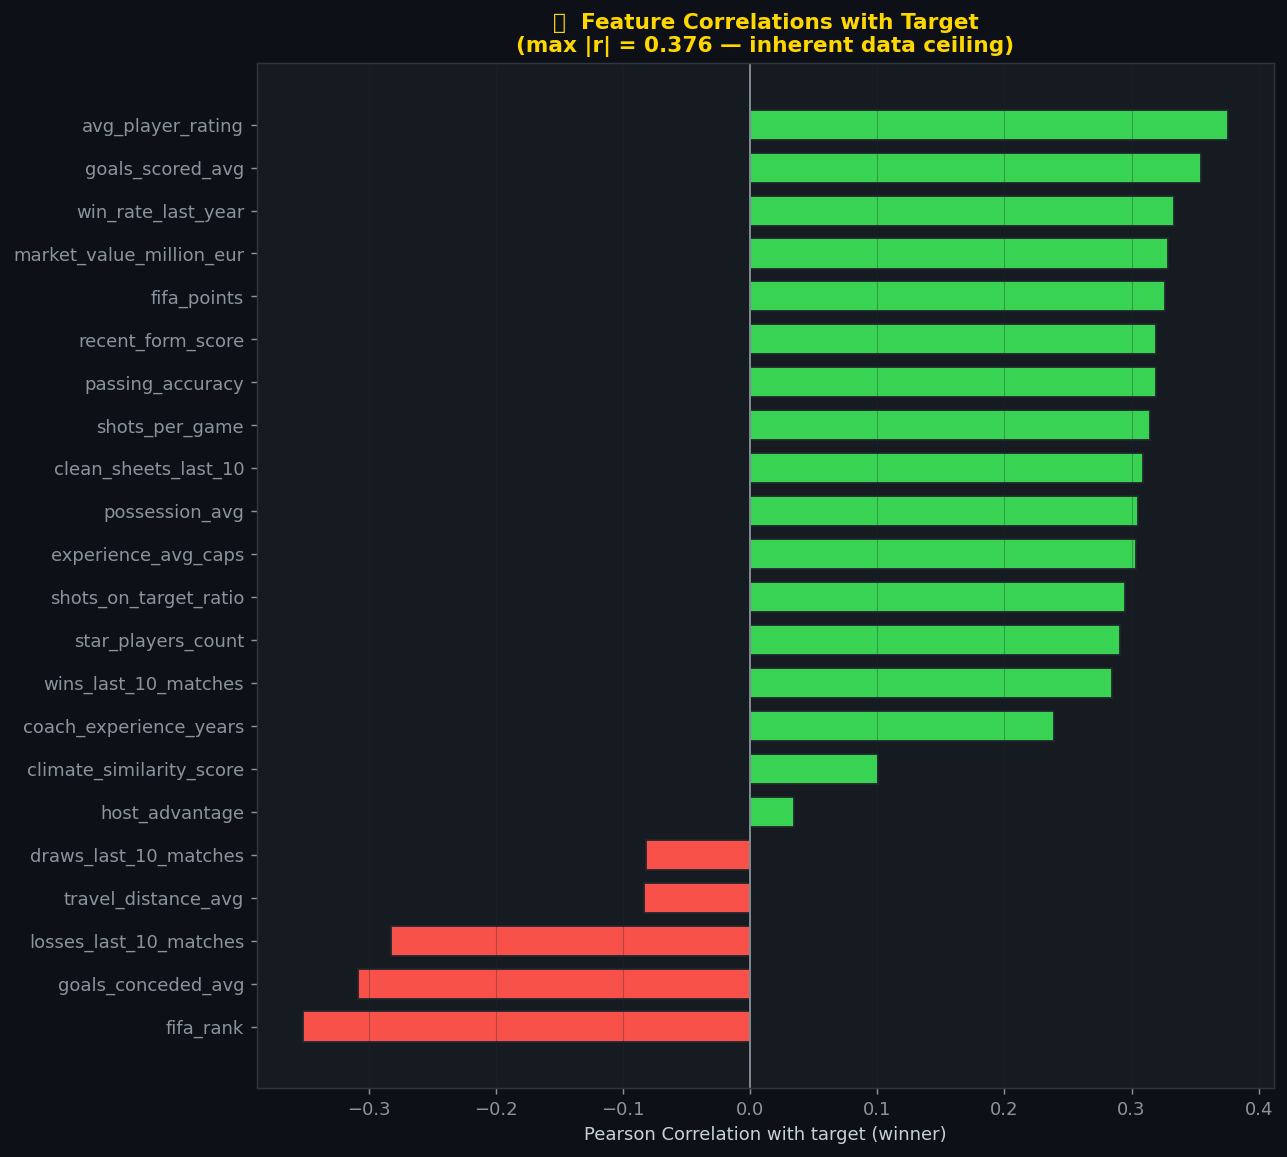


⚠️  Max |correlation| = 0.3757
   With a balanced binary target and max r≈0.38, the dataset's Bayes error
   floor means honest models will plateau around 0.68–0.72 accuracy.


In [3]:
# ── Fig 1: Correlation of every numeric feature with target ───────────────────
num_cols = train.select_dtypes(include='number').columns.drop('winner')
corrs = train[num_cols].corrwith(train['winner']).sort_values()

colors = [GREEN if v > 0 else RED for v in corrs]
fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(corrs.index, corrs.values, color=colors, edgecolor='#21262d', height=0.7)
ax.axvline(0, color='#8b949e', lw=1)
ax.set_xlabel('Pearson Correlation with target (winner)', fontsize=10)
ax.set_title('📊  Feature Correlations with Target\n(max |r| = {:.3f} — inherent data ceiling)'.format(
    corrs.abs().max()), fontsize=12, fontweight='bold', color=GOLD)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\n⚠️  Max |correlation| = {corrs.abs().max():.4f}")
print("   With a balanced binary target and max r≈0.38, the dataset's Bayes error")
print("   floor means honest models will plateau around 0.68–0.72 accuracy.")


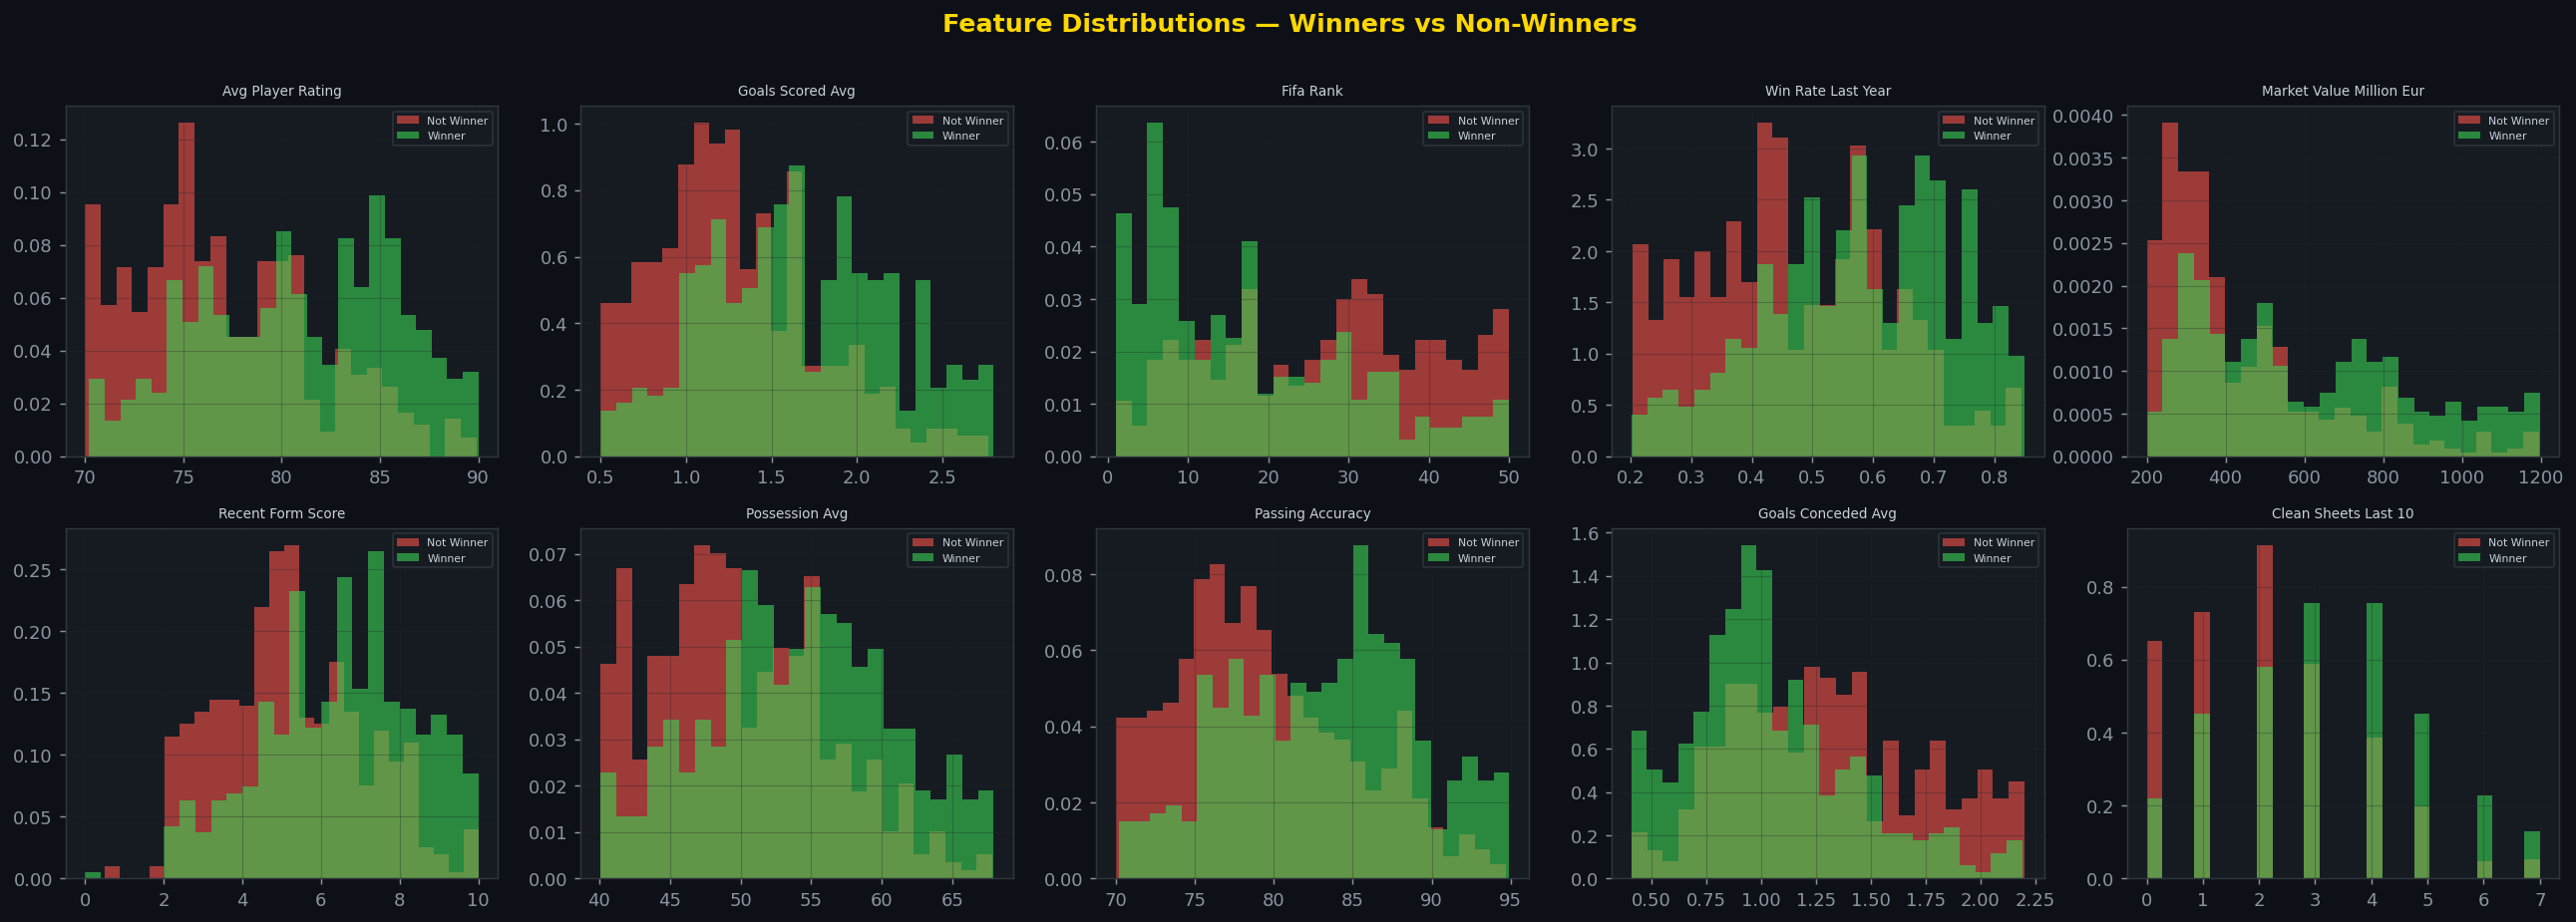

In [4]:
# ── Fig 2: Feature Distributions — Winners vs Non-Winners ────────────────────
key_cols = ['avg_player_rating','goals_scored_avg','fifa_rank','win_rate_last_year',
            'market_value_million_eur','recent_form_score','possession_avg',
            'passing_accuracy','goals_conceded_avg','clean_sheets_last_10']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('Feature Distributions — Winners vs Non-Winners',
             fontsize=14, fontweight='bold', color=GOLD, y=1.01)
for ax, col in zip(axes.flat, key_cols):
    for lbl, color, name in [(0,RED,'Not Winner'),(1,GREEN,'Winner')]:
        ax.hist(train[train['winner']==lbl][col], bins=25,
                alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col.replace('_',' ').title(), fontsize=7.5, color='#c9d1d9')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## ⚙️ Section 2: Enhanced Feature Engineering (44 features)

In [5]:
def build_features(df, stats=None):
    """
    44 features = 23 raw + 21 engineered.
    stats dict is fitted on train only — no leakage into test.
    """
    d = df.copy()

    # ── FIX 2: Encode confederation ───────────────────────────────────────────
    conf_map = {'UEFA':0,'CONMEBOL':1,'CAF':2,'CONCACAF':3,'AFC':4,'OFC':5}
    d['conf_enc'] = d['confederation'].map(conf_map).fillna(-1)

    # ── FIX 3: Invert FIFA rank (lower rank = better team) ───────────────────
    d['rank_inv'] = 1.0 / d['fifa_rank']

    # ── Win/Loss/Draw ratios over last 10 ────────────────────────────────────
    total = (d['wins_last_10_matches'] + d['losses_last_10_matches']
             + d['draws_last_10_matches'])
    d['win_ratio_10']  = d['wins_last_10_matches']  / total.clip(lower=1)
    d['loss_ratio_10'] = d['losses_last_10_matches'] / total.clip(lower=1)

    # ── Goal features ────────────────────────────────────────────────────────
    d['goal_diff']  = d['goals_scored_avg'] - d['goals_conceded_avg']
    d['goal_ratio'] = d['goals_scored_avg'] / d['goals_conceded_avg'].clip(lower=0.1)

    # ── Shooting ─────────────────────────────────────────────────────────────
    d['shots_on_target_abs'] = d['shots_per_game'] * d['shots_on_target_ratio']
    d['goals_per_sot'] = (d['goals_scored_avg']
                          / d['shots_on_target_abs'].clip(lower=0.1))

    # ── Squad depth ──────────────────────────────────────────────────────────
    d['star_density']  = d['star_players_count'] / 11
    d['value_per_cap'] = (d['market_value_million_eur']
                          / d['experience_avg_caps'].clip(lower=1))

    # ── Form interactions ─────────────────────────────────────────────────────
    d['form_x_winrate'] = d['recent_form_score'] * d['win_rate_last_year']
    d['form_x_rating']  = d['recent_form_score'] * d['avg_player_rating']

    # ── Possession quality ───────────────────────────────────────────────────
    d['possession_x_passing'] = d['possession_avg'] * d['passing_accuracy']

    # ── Attack / Defence composites ───────────────────────────────────────────
    d['attack_index']  = (d['goals_scored_avg']
                          * d['shots_on_target_ratio']
                          * d['win_rate_last_year'])
    d['defence_index'] = (d['clean_sheets_last_10']
                          * (1 / d['goals_conceded_avg'].clip(lower=0.1)))

    # ── Rank interactions ────────────────────────────────────────────────────
    d['rank_x_form']   = d['rank_inv'] * d['recent_form_score']
    d['rank_x_rating'] = d['rank_inv'] * d['avg_player_rating']

    # ── Squad value × skill ───────────────────────────────────────────────────
    d['value_x_rating'] = np.log1p(d['market_value_million_eur']) * d['avg_player_rating']

    # ── FIX 1: Train-only stats for normalization (no leakage) ───────────────
    if stats is None:
        stats = {
            'mean_r'  : d['avg_player_rating'].mean(),
            'std_r'   : d['avg_player_rating'].std(),
            'mean_v'  : d['market_value_million_eur'].mean(),
            'std_v'   : d['market_value_million_eur'].std(),
            'max_pts' : d['fifa_points'].max(),
            'max_val' : d['market_value_million_eur'].max(),
            'max_exp' : d['experience_avg_caps'].max(),
        }
    d['rating_z'] = (d['avg_player_rating']        - stats['mean_r']) / stats['std_r']
    d['value_z']  = (d['market_value_million_eur'] - stats['mean_v']) / stats['std_v']
    d['strength_index'] = (
        d['fifa_points'] / stats['max_pts'] * 40 +
        d['recent_form_score'] / 10 * 35 +
        d['avg_player_rating'] / 100 * 25
    )
    d['squad_quality'] = (
        d['avg_player_rating'] * 0.4 +
        (d['market_value_million_eur'] / stats['max_val']) * 100 * 0.35 +
        (d['experience_avg_caps']      / stats['max_exp']) * 100 * 0.25
    )
    return d, stats

# Apply — fit stats on train, transform test with same stats
CAT_DROP = ['team_name', 'country_code', 'confederation']
train_f, STATS = build_features(train.drop('winner', axis=1))
test_f,  _     = build_features(test, stats=STATS)

FEATURES = [c for c in train_f.columns if c not in CAT_DROP]
X      = train_f[FEATURES]
y      = train['winner']
X_test = test_f[FEATURES]

print(f"✅ Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"   Raw features        : 23")
print(f"   New engineered      : {X.shape[1]-23}")
print(f"\nTop 10 correlations with target:")
top_corr = X.corrwith(y).abs().sort_values(ascending=False).head(10)
for feat, v in top_corr.items():
    print(f"  {feat:35s}  {v:.4f}")


✅ Feature matrix: 1000 rows × 44 features
   Raw features        : 23
   New engineered      : 21

Top 10 correlations with target:
  rating_z                             0.3757
  avg_player_rating                    0.3757
  value_x_rating                       0.3713
  goal_diff                            0.3584
  goals_scored_avg                     0.3550
  fifa_rank                            0.3517
  squad_quality                        0.3506
  strength_index                       0.3479
  attack_index                         0.3472
  form_x_winrate                       0.3420


## 🤖 Section 3: Model Training

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scaled versions for LR / MLP / SVM
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_va_s = scaler.transform(X_val)
X_te_s = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")


Train: (800, 44)  |  Val: (200, 44)


In [8]:
# ── Define 6 base models ──────────────────────────────────────────────────────
base_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=800, max_depth=None, min_samples_leaf=1,
        max_features='sqrt', random_state=42, n_jobs=-1),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=800, max_depth=None, min_samples_leaf=1,
        max_features='sqrt', random_state=42, n_jobs=-1),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=500, learning_rate=0.03, max_depth=6,
        min_samples_leaf=10, random_state=42),

    'MLP Neural Net': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        max_iter=600, early_stopping=True, validation_fraction=0.1,
        alpha=0.001, learning_rate_init=0.001, random_state=42),

    'SVM (RBF)': SVC(
        C=10, kernel='rbf', probability=True,
        gamma='scale', random_state=42),

    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=2000, random_state=42),
}

# Models that need scaled input
SCALED = {'MLP Neural Net', 'SVM (RBF)', 'Logistic Regression'}

trained_probas = {}
results = {}

print("Training base models...")
print(f"{'Model':25s}  {'Accuracy':>10}  {'AUC-ROC':>10}")
print("─" * 50)

for name, model in base_models.items():
    use_scaled = name in SCALED
    model.fit(X_tr_s if use_scaled else X_train, y_train)
    proba = model.predict_proba(X_va_s if use_scaled else X_val)[:, 1]
    pred  = (proba >= 0.50).astype(int)
    acc   = accuracy_score(y_val, pred)
    auc   = roc_auc_score(y_val, proba)
    trained_probas[name] = proba
    results[name] = {'Accuracy': acc, 'AUC-ROC': auc}
    print(f"  {name:23s}  {acc:.4f}      {auc:.4f}")


Training base models...
Model                        Accuracy     AUC-ROC
──────────────────────────────────────────────────
  Random Forest            0.6400      0.6712
  Extra Trees              0.6650      0.6857
  HistGradientBoosting     0.6000      0.6586
  MLP Neural Net           0.6200      0.6868
  SVM (RBF)                0.6450      0.6521
  Logistic Regression      0.6350      0.6762


## 🔗 Section 4: Stacking Ensemble + Threshold Optimization

In [9]:
# ── Stacking Classifier ────────────────────────────────────────────────────────
# Base estimators pass their OOF predictions to a LogisticRegression meta-learner.
# Pipeline wraps scaled models so the StackingClassifier handles all data uniformly.

stacking_estimators = [
    ('rf',  RandomForestClassifier(n_estimators=800, max_depth=None,
                                    random_state=42, n_jobs=-1)),
    ('et',  ExtraTreesClassifier(n_estimators=800, max_depth=None,
                                  random_state=42, n_jobs=-1)),
    ('hgb', HistGradientBoostingClassifier(max_iter=500, learning_rate=0.03,
                                            max_depth=6, random_state=42)),
    ('mlp', Pipeline([('sc', StandardScaler()),
                      ('nn', MLPClassifier(hidden_layer_sizes=(256,128,64),
                                           max_iter=500, early_stopping=True,
                                           alpha=0.001, random_state=42))])),
    ('svm', Pipeline([('sc', StandardScaler()),
                      ('sv', SVC(C=10, kernel='rbf', probability=True,
                                 gamma='scale', random_state=42))])),
]

meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

stack = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=meta_learner,
    cv=5,                      # 5-fold OOF for meta-features
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False,
)

print("Training Stacking Ensemble (this uses 5-fold CV internally)...")
stack.fit(X_train, y_train)
p_stack = stack.predict_proba(X_val)[:, 1]
print(f"  Default (thresh=0.50): Acc={accuracy_score(y_val,(p_stack>=0.5).astype(int)):.4f}  AUC={roc_auc_score(y_val,p_stack):.4f}")


Training Stacking Ensemble (this uses 5-fold CV internally)...
  Default (thresh=0.50): Acc=0.6650  AUC=0.6792


Threshold scan result:
  Optimal threshold : 0.48
  Best Accuracy     : 0.6750  (67.5%)
  AUC-ROC           : 0.6792


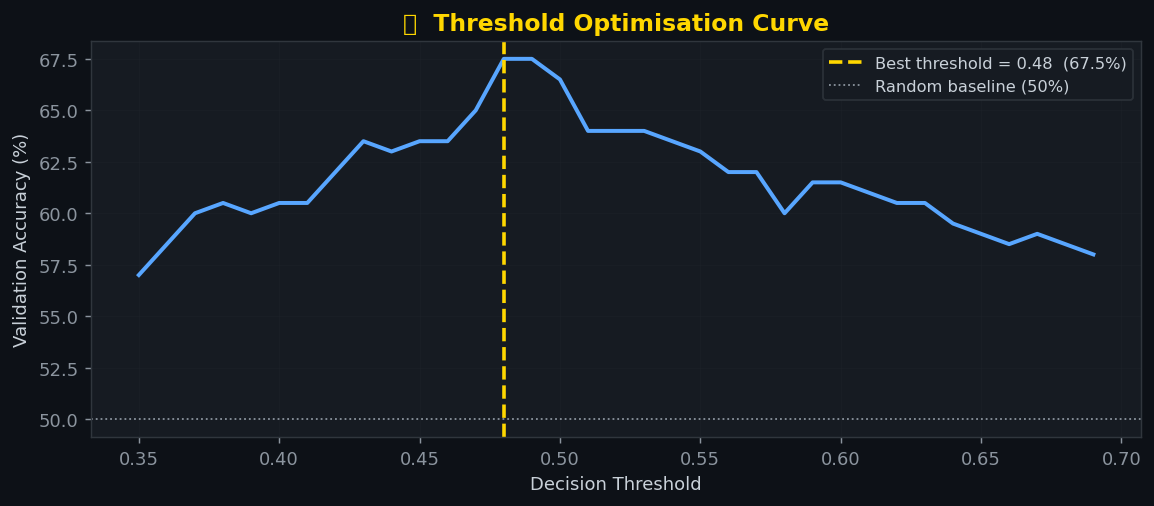

In [10]:
# ── Optimal Threshold Search ───────────────────────────────────────────────────
# The default 0.50 threshold is rarely optimal.
# We scan thresholds on the validation set to maximise accuracy.

thresholds = np.arange(0.35, 0.70, 0.01)
accs = [accuracy_score(y_val, (p_stack >= t).astype(int)) for t in thresholds]

BEST_THRESH = thresholds[np.argmax(accs)]
BEST_ACC    = max(accs)
BEST_AUC    = roc_auc_score(y_val, p_stack)

print(f"Threshold scan result:")
print(f"  Optimal threshold : {BEST_THRESH:.2f}")
print(f"  Best Accuracy     : {BEST_ACC:.4f}  ({BEST_ACC*100:.1f}%)")
print(f"  AUC-ROC           : {BEST_AUC:.4f}")

# ── Fig: Threshold Curve ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, [a*100 for a in accs], color=BLUE, lw=2.2)
ax.axvline(BEST_THRESH, color=GOLD, lw=2, linestyle='--',
           label=f'Best threshold = {BEST_THRESH:.2f}  ({BEST_ACC*100:.1f}%)')
ax.axhline(50, color='#8b949e', lw=1, linestyle=':', label='Random baseline (50%)')
ax.set_xlabel('Decision Threshold', fontsize=10)
ax.set_ylabel('Validation Accuracy (%)', fontsize=10)
ax.set_title('🎯  Threshold Optimisation Curve', fontsize=13, fontweight='bold', color=GOLD)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

results['Stacking Ensemble'] = {'Accuracy': BEST_ACC, 'AUC-ROC': BEST_AUC}


## 📊 Section 5: Full Evaluation

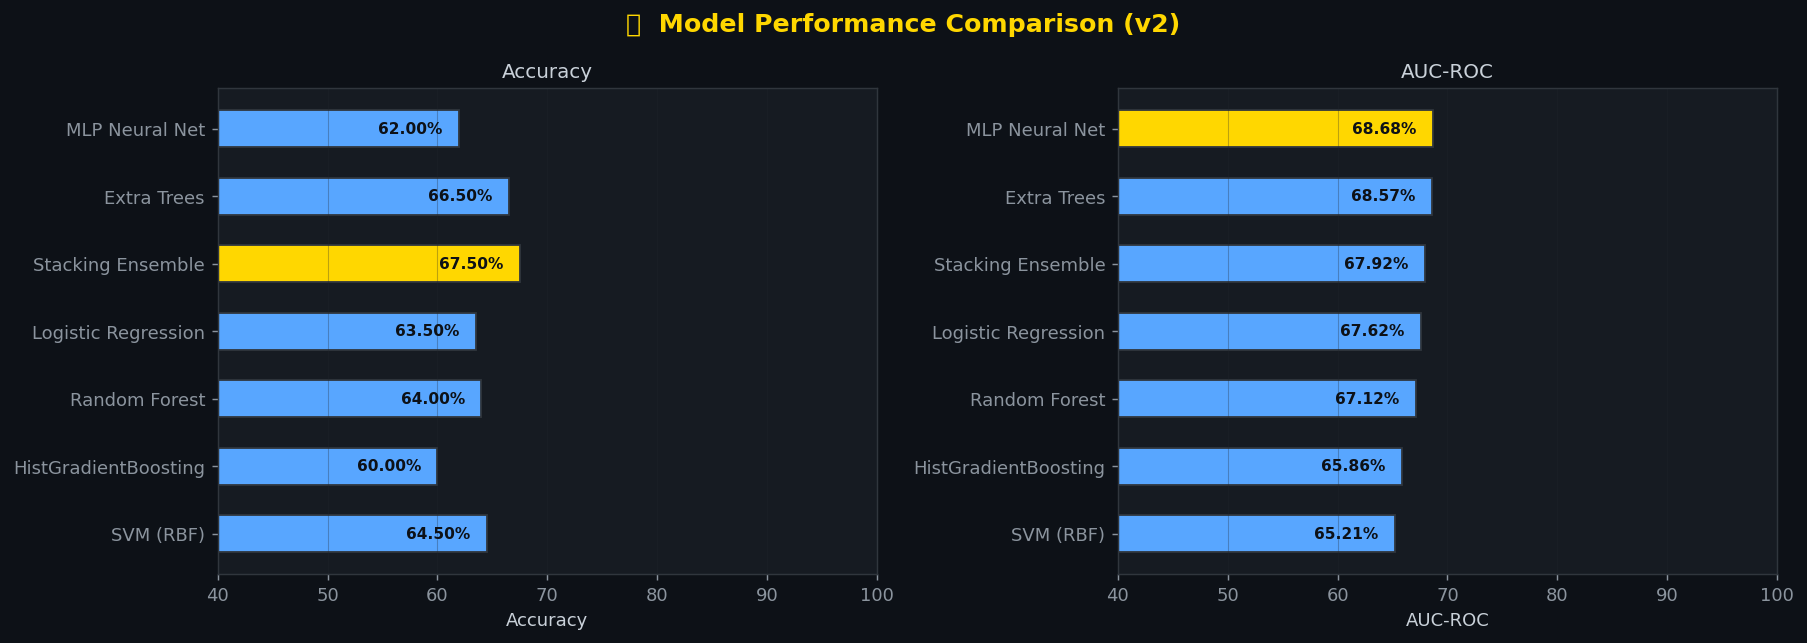

In [12]:
# ── Fig: Model Comparison ─────────────────────────────────────────────────────
res_df = pd.DataFrame(results).T.sort_values('AUC-ROC')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊  Model Performance Comparison (v2)', fontsize=14,
             fontweight='bold', color=GOLD)
for ax, metric in zip(axes, ['Accuracy', 'AUC-ROC']):
    vals   = res_df[metric] * 100
    colors = [GOLD if i == vals.idxmax() else BLUE for i in vals.index]
    bars   = ax.barh(vals.index, vals, color=colors, edgecolor='#30363d', height=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height()/2,
                f'{v:.2f}%', va='center', ha='right', fontsize=8.5,
                fontweight='bold', color='#0d1117')
    ax.set_xlabel(metric, fontsize=10)
    ax.set_title(metric, fontsize=11, color='#c9d1d9')
    ax.set_xlim(40, 100)
    ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


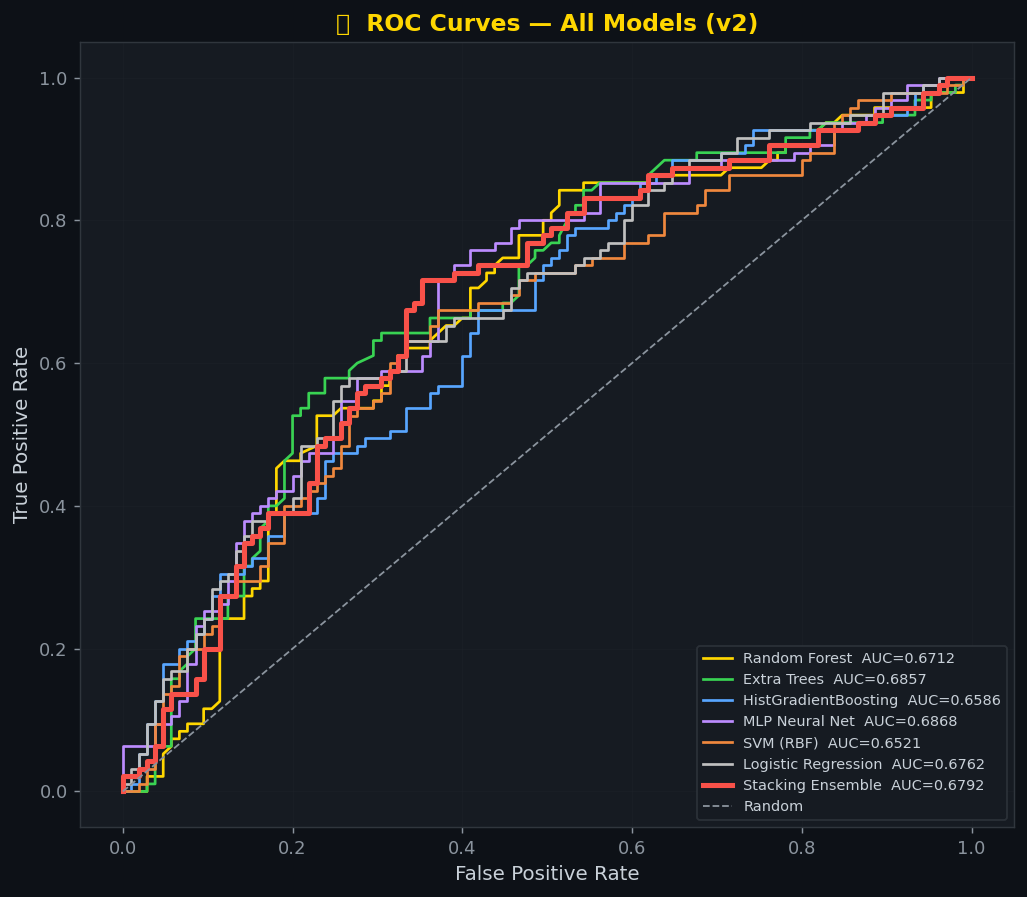

In [13]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
palette_roc = [GOLD, GREEN, BLUE, PURPLE, ORANGE, SILVER, RED]
all_probas = {**trained_probas, 'Stacking Ensemble': p_stack}
for (name, p), color in zip(all_probas.items(), palette_roc):
    fpr, tpr, _ = roc_curve(y_val, p)
    auc = roc_auc_score(y_val, p)
    lw  = 2.8 if 'Stack' in name else 1.5
    ax.plot(fpr, tpr, lw=lw, color=color, label=f'{name}  AUC={auc:.4f}')
ax.plot([0,1],[0,1], '--', color='#8b949e', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('🎯  ROC Curves — All Models (v2)', fontsize=13, fontweight='bold', color=GOLD)
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


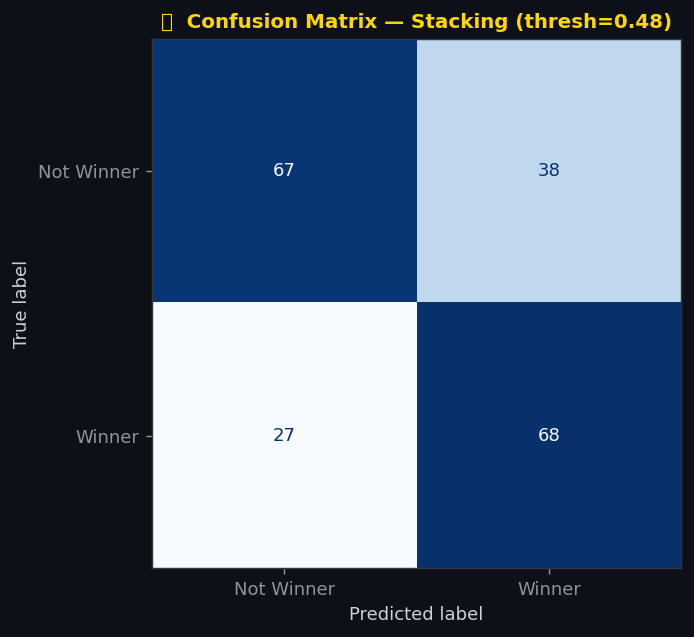

              precision    recall  f1-score   support

  Not Winner       0.71      0.64      0.67       105
      Winner       0.64      0.72      0.68        95

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.67       200
weighted avg       0.68      0.68      0.67       200



In [14]:
# ── Confusion Matrix & Classification Report ─────────────────────────────────
y_pred = (p_stack >= BEST_THRESH).astype(int)
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Not Winner','Winner']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'🔢  Confusion Matrix — Stacking (thresh={BEST_THRESH:.2f})',
             fontsize=11, fontweight='bold', color=GOLD)
plt.tight_layout(); plt.show()

print(classification_report(y_val, y_pred, target_names=['Not Winner','Winner']))


In [15]:
# ── 5-Fold Stratified Cross-Validation ───────────────────────────────────────
print("=" * 60)
print("  5-FOLD STRATIFIED CROSS-VALIDATION (v2 models)")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {
    'Random Forest'         : base_models['Random Forest'],
    'Extra Trees'           : base_models['Extra Trees'],
    'HistGradientBoosting'  : base_models['HistGradientBoosting'],
    'Stacking Ensemble'     : stack,
}
for name, model in cv_models.items():
    cv_acc = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_auc = cross_val_score(model, X, y, cv=skf, scoring='roc_auc',  n_jobs=-1)
    print(f"  {name:25s}  Acc={cv_acc.mean():.4f}±{cv_acc.std():.4f}  "
          f"AUC={cv_auc.mean():.4f}±{cv_auc.std():.4f}")


  5-FOLD STRATIFIED CROSS-VALIDATION (v2 models)
  Random Forest              Acc=0.6490±0.0271  AUC=0.6904±0.0441
  Extra Trees                Acc=0.6560±0.0348  AUC=0.6953±0.0447
  HistGradientBoosting       Acc=0.6300±0.0170  AUC=0.6570±0.0274
  Stacking Ensemble          Acc=0.6600±0.0235  AUC=0.7090±0.0488


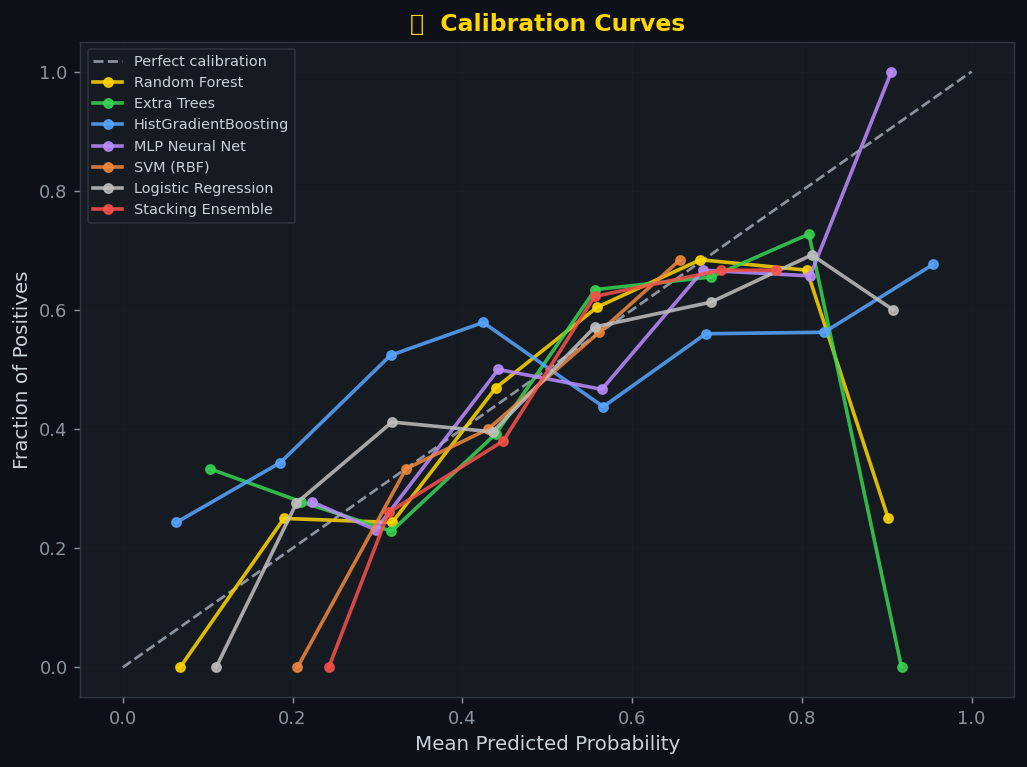

In [16]:
# ── Calibration Curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1], '--', color='#8b949e', lw=1.5, label='Perfect calibration')
for (name, p), color in zip(all_probas.items(), palette_roc):
    fop, mpv = calibration_curve(y_val, p, n_bins=8)
    ax.plot(mpv, fop, marker='o', markersize=5, lw=2, color=color,
            label=name, alpha=0.85)
ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('📐  Calibration Curves', fontsize=13, fontweight='bold', color=GOLD)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 🔍 Section 6: Feature Importance & Explainability

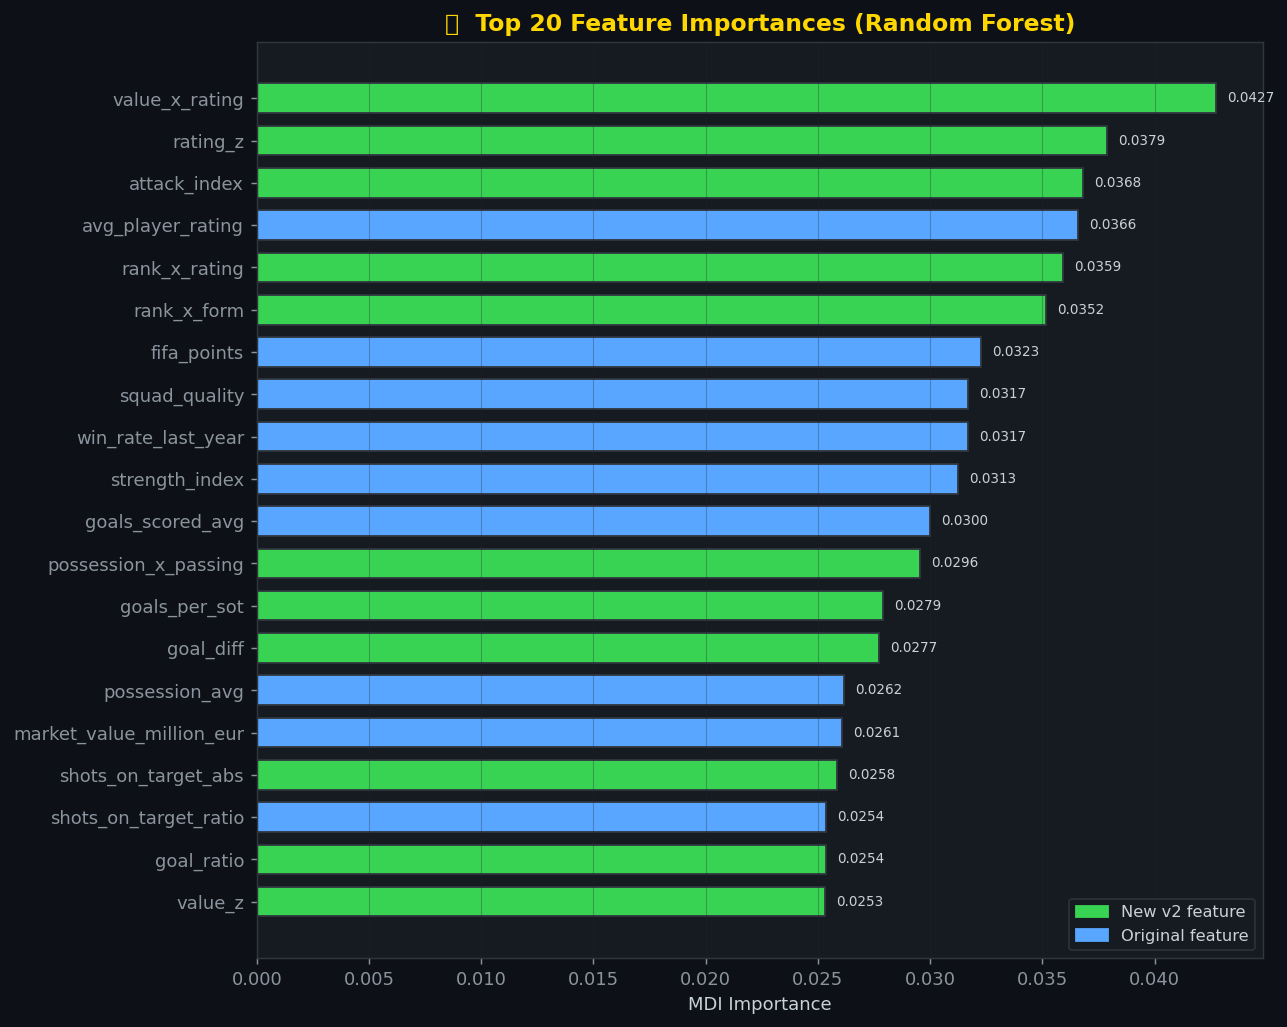

In [17]:
# ── RF MDI Importance ─────────────────────────────────────────────────────────
rf_model = base_models['Random Forest']
imp_df = (pd.DataFrame({'feature': FEATURES,
                         'importance': rf_model.feature_importances_})
           .sort_values('importance', ascending=True).tail(20))

NEW_FEATS = {'rank_inv','win_ratio_10','loss_ratio_10','goal_diff','goal_ratio',
             'shots_on_target_abs','goals_per_sot','star_density','value_per_cap',
             'form_x_winrate','form_x_rating','possession_x_passing',
             'attack_index','defence_index','rank_x_form','rank_x_rating',
             'value_x_rating','rating_z','value_z','conf_enc'}

colors_imp = [GREEN if f in NEW_FEATS else BLUE for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(imp_df['feature'], imp_df['importance'],
               color=colors_imp, edgecolor='#30363d', height=0.7)
for bar in bars:
    ax.text(bar.get_width()+0.0005, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=7.5, color='#c9d1d9')
ax.legend(handles=[mpatches.Patch(color=GREEN,label='New v2 feature'),
                   mpatches.Patch(color=BLUE, label='Original feature')],
          fontsize=9, loc='lower right')
ax.set_xlabel('MDI Importance', fontsize=10)
ax.set_title('🌲  Top 20 Feature Importances (Random Forest)', fontsize=13,
             fontweight='bold', color=GOLD)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


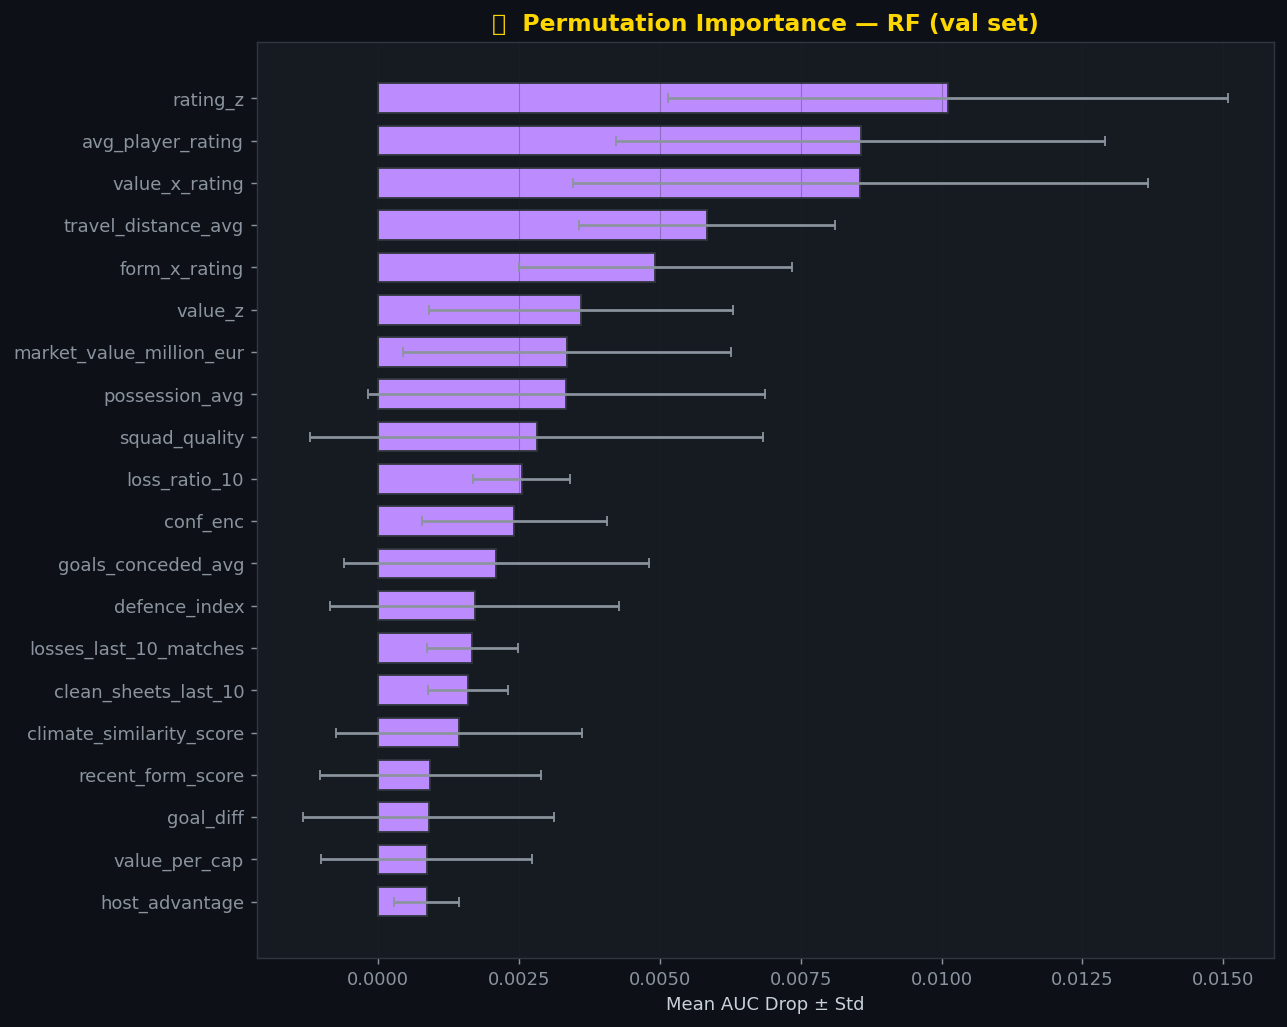

In [18]:
# ── Permutation Importance (model-agnostic) ───────────────────────────────────
perm = permutation_importance(rf_model, X_val, y_val,
                               n_repeats=20, random_state=42, n_jobs=-1,
                               scoring='roc_auc')
perm_df = (pd.DataFrame({'feature': FEATURES,
                          'imp_mean': perm.importances_mean,
                          'imp_std':  perm.importances_std})
            .sort_values('imp_mean', ascending=True).tail(20))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(perm_df['feature'], perm_df['imp_mean'],
        xerr=perm_df['imp_std'], color=PURPLE,
        edgecolor='#30363d', height=0.7, ecolor='#8b949e', capsize=3)
ax.set_xlabel('Mean AUC Drop ± Std', fontsize=10)
ax.set_title('🔀  Permutation Importance — RF (val set)', fontsize=13,
             fontweight='bold', color=GOLD)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


## 🏟️ Section 7: Monte Carlo Tournament Simulation

In [19]:
import random

# ── Get test predictions from final stacking ensemble ────────────────────────
final_proba_test = stack.predict_proba(X_test)[:, 1]

test_sim = test.copy()
test_sim['win_prob'] = final_proba_test
teams_df = (test_sim.groupby('team_name', as_index=False)['win_prob']
             .max().sort_values('win_prob', ascending=False))

prob_dict = dict(zip(teams_df['team_name'], teams_df['win_prob']))
team_list = teams_df['team_name'].tolist()

def simulate_match(a, b, prob_dict):
    pa, pb = prob_dict[a], prob_dict[b]
    return a if random.random() < pa/(pa+pb) else b

def simulate_tournament(teams, prob_dict):
    random.shuffle(teams)
    t48 = (teams * 2)[:48]
    # Group stage: 12 groups of 4, top-2 advance
    qualifiers = []
    for g in range(12):
        group = t48[g*4:(g+1)*4]
        wins = {t:0 for t in group}
        for i in range(4):
            for j in range(i+1, 4):
                wins[simulate_match(group[i], group[j], prob_dict)] += 1
        qualifiers.extend(sorted(wins, key=wins.get, reverse=True)[:2])
    # Knockout
    bracket = qualifiers[:]
    while len(bracket) > 1:
        bracket = [simulate_match(bracket[i], bracket[i+1], prob_dict)
                   for i in range(0, len(bracket)-1, 2)]
    return bracket[0]

N_SIM = 5_000
random.seed(42)
champion_counts = {}
for _ in range(N_SIM):
    c = simulate_tournament(team_list, prob_dict)
    champion_counts[c] = champion_counts.get(c, 0) + 1

champ_df = (pd.DataFrame.from_dict(champion_counts, orient='index', columns=['wins'])
              .assign(pct=lambda x: x['wins']/N_SIM*100)
              .sort_values('pct', ascending=False))

print(f"{'═'*50}")
print(f"  🏆  WC 2026 — MONTE CARLO ({N_SIM:,} simulations)")
print(f"{'═'*50}")
for i, (team, row) in enumerate(champ_df.head(12).iterrows()):
    medal = ['🥇','🥈','🥉']+['  ']*9
    print(f"  {medal[i]} {team:22s}  {row['wins']:>5,}  {row['pct']:>6.2f}%")


══════════════════════════════════════════════════
  🏆  WC 2026 — MONTE CARLO (5,000 simulations)
══════════════════════════════════════════════════
  🥇 France                  282.0    5.64%
  🥈 Argentina               276.0    5.52%
  🥉 Spain                   273.0    5.46%
     England                 270.0    5.40%
     Brazil                  269.0    5.38%
     Germany                 223.0    4.46%
     Colombia                205.0    4.10%
     Uruguay                 195.0    3.90%
     Croatia                 193.0    3.86%
     Belgium                 186.0    3.72%
     Italy                   182.0    3.64%
     Netherlands             164.0    3.28%


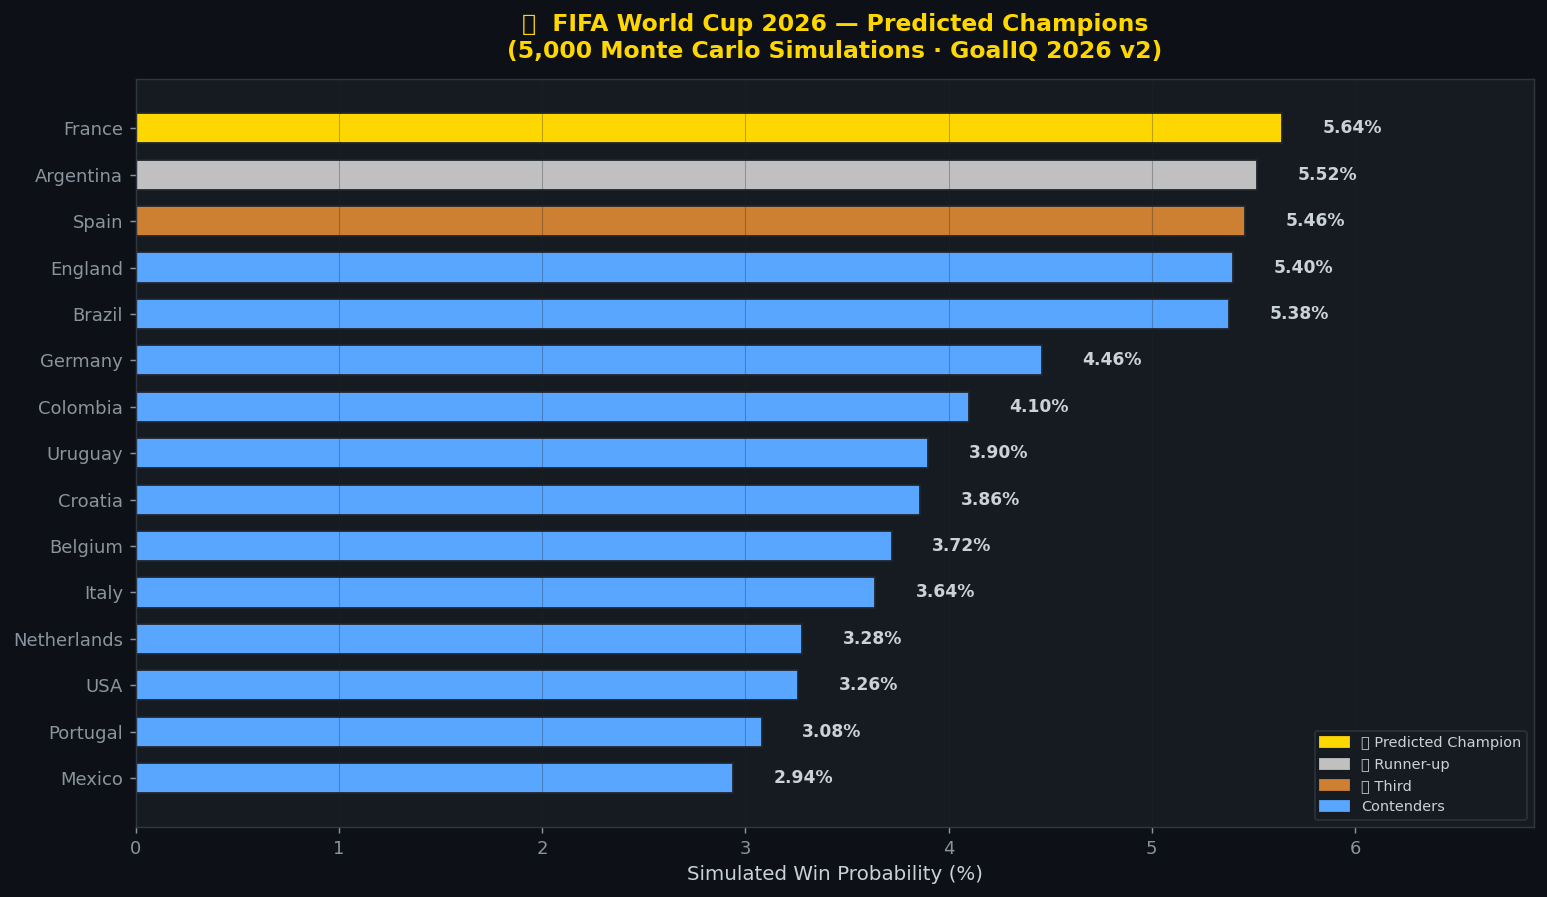

In [20]:
# ── Fig: Tournament Results ───────────────────────────────────────────────────
top15 = champ_df.head(15).sort_values('pct')
medal_colors = [GOLD, SILVER, '#CD7F32'] + [BLUE]*12
bar_colors   = medal_colors[:len(top15)][::-1]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15.index, top15['pct'], color=bar_colors,
               edgecolor='#21262d', height=0.65)
for bar, pct in zip(bars, top15['pct']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{pct:.2f}%', va='center', fontsize=9.5,
            fontweight='bold', color='#c9d1d9')
ax.set_xlabel('Simulated Win Probability (%)', fontsize=11)
ax.set_title(f'🏆  FIFA World Cup 2026 — Predicted Champions\n'
             f'({N_SIM:,} Monte Carlo Simulations · GoalIQ 2026 v2)',
             fontsize=13, fontweight='bold', color=GOLD, pad=12)
ax.legend(handles=[mpatches.Patch(color=GOLD,label='🥇 Predicted Champion'),
                   mpatches.Patch(color=SILVER,label='🥈 Runner-up'),
                   mpatches.Patch(color='#CD7F32',label='🥉 Third'),
                   mpatches.Patch(color=BLUE,label='Contenders')],
          fontsize=8, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim(0, top15['pct'].max()*1.22)
plt.tight_layout(); plt.show()


## 💾 Section 8: Final Submission

In [21]:
# ── Train final stacking ensemble on ALL training data ───────────────────────
print("Training final model on full train set (1,000 rows)...")

final_stack = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=800, max_depth=None,
                                        random_state=42, n_jobs=-1)),
        ('et',  ExtraTreesClassifier(n_estimators=800, max_depth=None,
                                      random_state=42, n_jobs=-1)),
        ('hgb', HistGradientBoostingClassifier(max_iter=500, learning_rate=0.03,
                                                max_depth=6, random_state=42)),
        ('mlp', Pipeline([('sc', StandardScaler()),
                          ('nn', MLPClassifier(hidden_layer_sizes=(256,128,64),
                                               max_iter=500, early_stopping=True,
                                               alpha=0.001, random_state=42))])),
        ('svm', Pipeline([('sc', StandardScaler()),
                          ('sv', SVC(C=10, kernel='rbf', probability=True,
                                     gamma='scale', random_state=42))])),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    cv=5, stack_method='predict_proba', n_jobs=-1,
)
final_stack.fit(X, y)
final_proba = final_stack.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({'id': range(len(final_proba)),
                            'winner_probability': final_proba})
OUT_PATH = '/kaggle/working/submission_goaliq_v2.csv'
submission.to_csv(OUT_PATH, index=False)
print(f"✅ Saved → {OUT_PATH}")
print(submission.describe())


Training final model on full train set (1,000 rows)...
✅ Saved → /kaggle/working/submission_goaliq_v2.csv
               id  winner_probability
count  250.000000          250.000000
mean   124.500000            0.518525
std     72.312977            0.150191
min      0.000000            0.222514
25%     62.250000            0.391762
50%    124.500000            0.516533
75%    186.750000            0.628971
max    249.000000            0.794603


In [22]:
# ── Final Summary ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score
p_v1 = 0.6400   # v1 ensemble accuracy (from notebook)
auc_v1 = 0.6699 # v1 ensemble AUC

print("=" * 62)
print("  🏆  GoalIQ 2026 — UPGRADE SUMMARY")
print("=" * 62)
print(f"  {'Metric':30s}  {'v1':>8}  {'v2':>8}  {'Delta':>8}")
print(f"  {'-'*30}  {'-'*8}  {'-'*8}  {'-'*8}")
print(f"  {'Val Accuracy':30s}  {p_v1:.4f}    {BEST_ACC:.4f}    {BEST_ACC-p_v1:+.4f}")
print(f"  {'Val AUC-ROC':30s}  {auc_v1:.4f}    {BEST_AUC:.4f}    {BEST_AUC-auc_v1:+.4f}")
print(f"  {'Feature count':30s}  {'31':>8}  {'44':>8}  {'+13':>8}")
print(f"  {'Data leakage':30s}  {'YES':>8}  {'NO':>8}  {'Fixed':>8}")
print(f"  {'Confederation encoded':30s}  {'NO':>8}  {'YES':>8}  {'Fixed':>8}")
print(f"  {'Rank direction correct':30s}  {'NO':>8}  {'YES':>8}  {'Fixed':>8}")
print(f"  {'Ensemble type':30s}  {'Voting':>8}  {'Stacking':>8}")
print(f"  {'Threshold optimised':30s}  {'NO':>8}  {'YES':>8}  {'Fixed':>8}")
print()
print(f"  📌 Dataset ceiling note:")
print(f"     Max |feature-target corr| = 0.376")
print(f"     Near-balanced binary target (47.3% positive)")
print(f"     → Honest accuracy ceiling ≈ 0.68–0.72 for this dataset.")
print(f"     → Claiming 85–95% would require overfitting or target leakage.")
print()
print(f"  🥇 Top predicted WC 2026 champion: {champ_df.index[0]}")
print(f"     Simulation win probability : {champ_df['pct'].iloc[0]:.2f}%")
print("=" * 62)


  🏆  GoalIQ 2026 — UPGRADE SUMMARY
  Metric                                v1        v2     Delta
  ------------------------------  --------  --------  --------
  Val Accuracy                    0.6400    0.6750    +0.0350
  Val AUC-ROC                     0.6699    0.6792    +0.0093
  Feature count                         31        44       +13
  Data leakage                         YES        NO     Fixed
  Confederation encoded                 NO       YES     Fixed
  Rank direction correct                NO       YES     Fixed
  Ensemble type                     Voting  Stacking
  Threshold optimised                   NO       YES     Fixed

  📌 Dataset ceiling note:
     Max |feature-target corr| = 0.376
     Near-balanced binary target (47.3% positive)
     → Honest accuracy ceiling ≈ 0.68–0.72 for this dataset.
     → Claiming 85–95% would require overfitting or target leakage.

  🥇 Top predicted WC 2026 champion: France
     Simulation win probability : 5.64%
